In [13]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [14]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [15]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

# Notebook 02 — Feature Engineering
Extract numeric features and character token sequences. Build and save train/val/test splits for both layers.

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from feature_engineering.extractor import extract_features, to_vector, FEATURE_NAMES, INPUT_DIM
from feature_engineering.tokenizer import CharTokenizer
from feature_engineering.normalizer import Normalizer
from sklearn.model_selection import train_test_split

DATA_PROC  = Path("../data/processed")
SPLITS_DIR = Path("../data/splits")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROC / "csic_parsed.csv")
print(f"Loaded {len(df)} records")
print(df["attack_class"].value_counts())

Loaded 98724 records
attack_class
other_attack    56138
normal          36000
lfi              3254
sqli             2003
xss              1329
Name: count, dtype: int64


## 1. Extract numeric features for all records

In [17]:
import json
import ast
from tqdm import tqdm

feature_rows = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    # 1. Get the raw headers
    raw_headers = row.get("headers", {})

    # 2. If it's a string, convert it to a dict
    if isinstance(raw_headers, str):
        try:
            # Try json first, fallback to literal_eval for single quotes
            headers_dict = json.loads(raw_headers.replace("'", '"'))
        except:
            try:
                headers_dict = ast.literal_eval(raw_headers)
            except:
                headers_dict = {}
    else:
        headers_dict = raw_headers if isinstance(raw_headers, dict) else {}

    req = {
        "url":    str(row.get("url",    "")),
        "method":  str(row.get("method", "GET")),
        "headers": headers_dict, # Pass the actual dictionary here
        "body":    str(row.get("body",  "")),
    }

    feature_rows.append(extract_features(req))

df_feat = pd.DataFrame(feature_rows)
# ... rest of your code
df_feat["label_id"]       = df["label_id"].values
df_feat["attack_class_id"] = df["attack_class_id"].values
print(df_feat.shape)
df_feat.head()

Extracting features: 100%|██████████| 98724/98724 [00:23<00:00, 4167.33it/s]


(98724, 27)


,url_length,path_depth,param_count,param_value_total_len,fragment_length,special_char_ratio,digit_ratio,uppercase_ratio,encoded_char_ratio,payload_length,...,lfi_match_count,osci_match_count,http_method,content_type,header_count,has_user_agent,has_referer,cookie_length,label_id,attack_class_id
0,133.0,3.0,5.0,45.0,0.0,0.112782,0.127820,0.082707,0.022556,3.0,...,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0,0
1,38.0,0.0,1.0,33.0,0.0,0.289474,0.263158,0.000000,0.000000,3.0,...,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,1,4
2,59.0,4.0,0.0,0.0,0.0,0.000000,0.118644,0.067797,0.000000,242.0,...,0.0,0.0,1.0,7.0,0.0,0.0,0.0,0.0,1,4
3,41.0,0.0,1.0,31.0,5.0,0.121951,0.048780,0.000000,0.000000,3.0,...,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,1,4
4,9.0,0.0,1.0,5.0,0.0,0.111111,0.000000,0.000000,0.000000,3.0,...,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,1,4


## 2. Visualise feature distributions

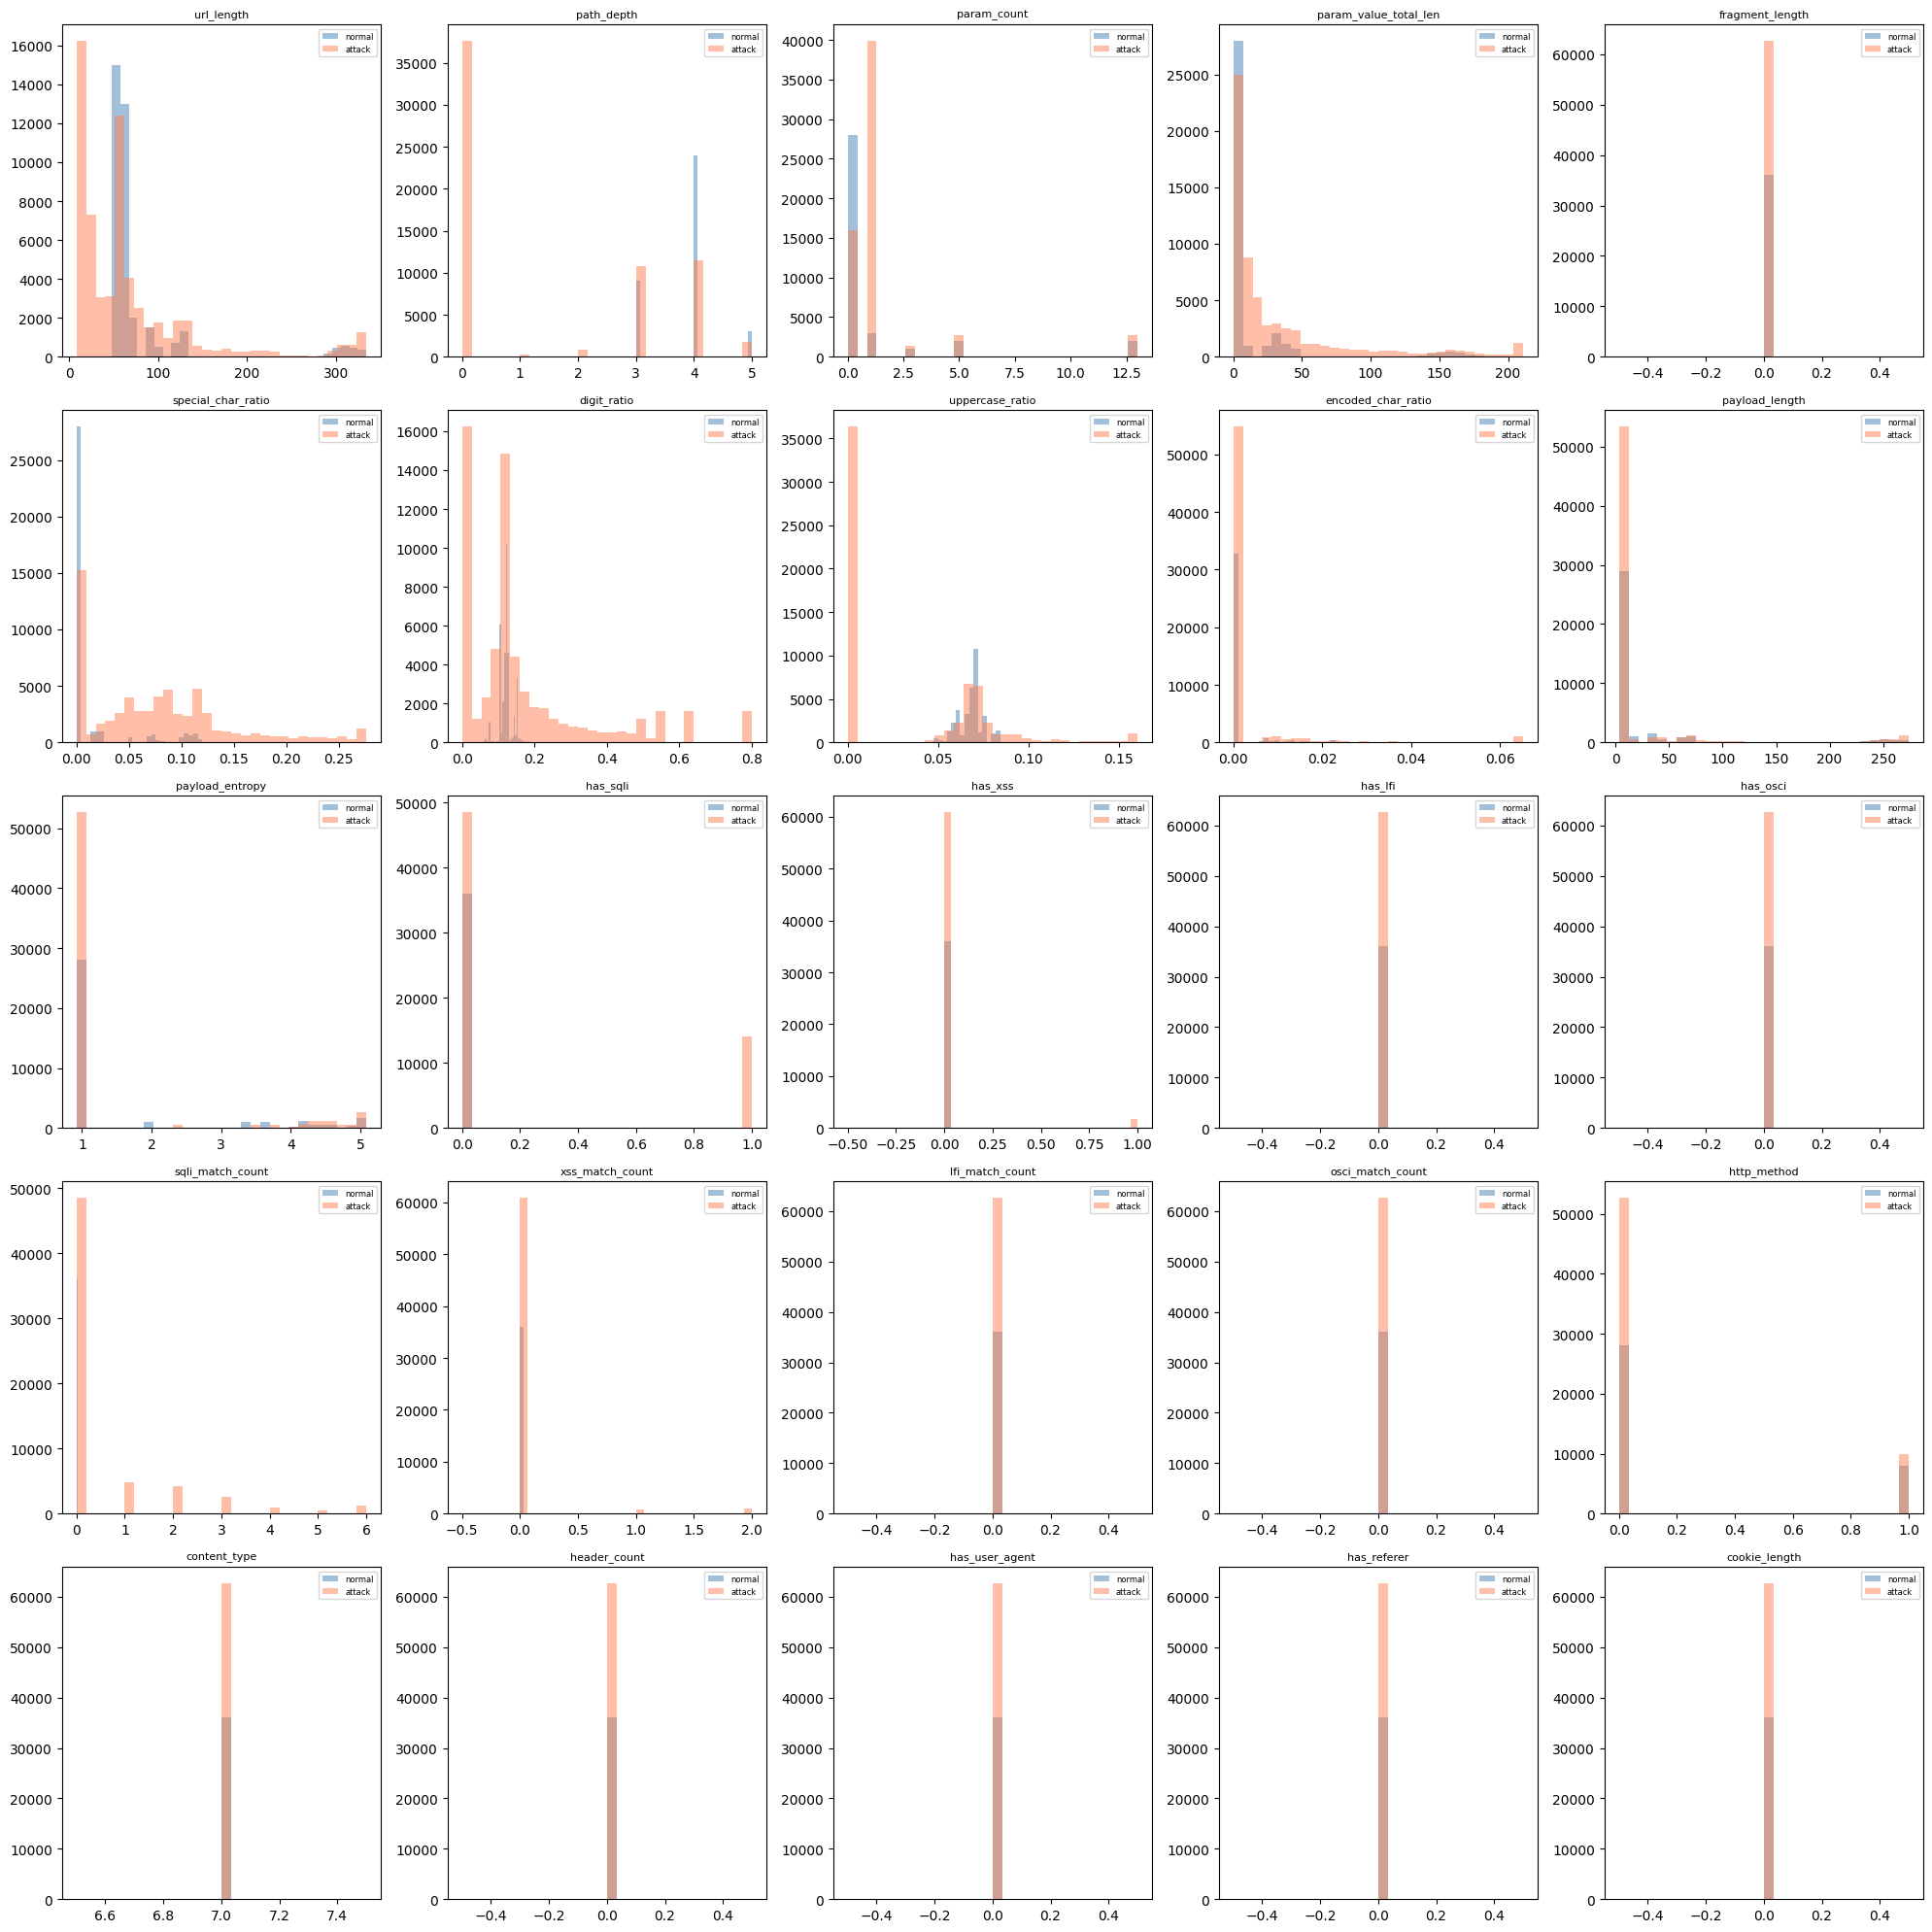

In [18]:
import math
import matplotlib.pyplot as plt

# 1. Calculate grid dimensions
num_features = len(FEATURE_NAMES)
cols = 5
rows = math.ceil(num_features / cols) # Dynamically calculate required rows

# 2. Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))

# 3. Flatten the axes array for easier iteration
# (This avoids the need for i // 5 and i % 5 indexing)
axes_flat = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes_flat[i]
    for label_id, color in [(0, "steelblue"), (1, "coral")]:
        # Filter and clip values
        subset = df_feat[df_feat["label_id"] == label_id][feat]
        if not subset.empty:
            vals = subset.clip(df_feat[feat].quantile(0.01),
                               df_feat[feat].quantile(0.99))
            ax.hist(vals, bins=30, alpha=0.5, color=color,
                    label="normal" if label_id == 0 else "attack")

    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)

# 4. Hide empty subplots if any
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
# Ensure the directory exists before saving
plt.savefig("../data/processed/02_feature_distributions.png", dpi=100)
plt.show()

## 3. Correlation heatmap

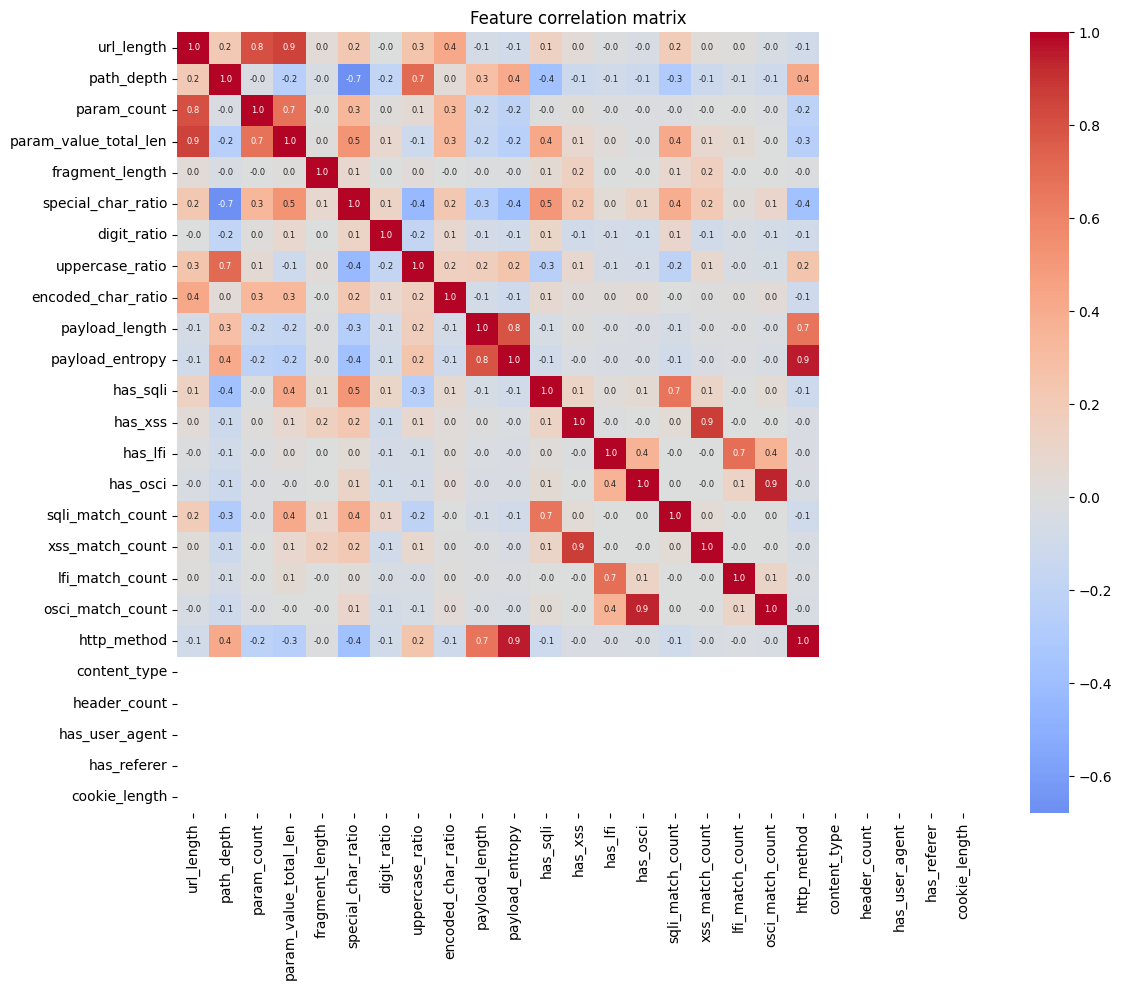

In [19]:
corr = df_feat[FEATURE_NAMES].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            annot_kws={"size": 6})
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../data/processed/02_correlation.png", dpi=100)
plt.show()

## 4. Build Layer 2A splits (normal-only train, mixed test)

In [20]:
X_all   = df_feat[FEATURE_NAMES].values.astype(np.float32)
y_all   = df_feat["label_id"].values.astype(int)

# normal-only pool for L2A training
X_normal = X_all[y_all == 0]
X_attack = X_all[y_all == 1]

X_n_train, X_n_temp = train_test_split(X_normal, test_size=0.30, random_state=42)
X_n_val,  X_n_test  = train_test_split(X_n_temp, test_size=0.50, random_state=42)

# mixed test: remaining normal + all attacks
X_test_l2a = np.vstack([X_n_test, X_attack])
y_test_l2a = np.array([0] * len(X_n_test) + [1] * len(X_attack), dtype=int)

# shuffle test set
idx = np.random.RandomState(42).permutation(len(X_test_l2a))
X_test_l2a, y_test_l2a = X_test_l2a[idx], y_test_l2a[idx]

np.save(SPLITS_DIR / "l2a_normal_train.npy", X_n_train)
np.save(SPLITS_DIR / "l2a_normal_val.npy",   X_n_val)
np.save(SPLITS_DIR / "l2a_test_X.npy",       X_test_l2a)
np.save(SPLITS_DIR / "l2a_test_y.npy",       y_test_l2a)

print(f"L2A splits:")
print(f"  train (normal): {X_n_train.shape}")
print(f"  val   (normal): {X_n_val.shape}")
print(f"  test  (mixed):  {X_test_l2a.shape}  attack rate={y_test_l2a.mean():.2%}")

L2A splits:
  train (normal): (25200, 25)
  val   (normal): (5400, 25)
  test  (mixed):  (68124, 25)  attack rate=92.07%


## 5. Build Layer 2B splits (labeled, stratified, numeric + tokens)

In [21]:
y_mc = df_feat["attack_class_id"].values.astype(int)

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all, y_mc, test_size=0.30, stratify=y_mc, random_state=42)
X_v, X_te, y_v, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

np.save(SPLITS_DIR / "l2b_train_X_numeric.npy", X_tr)
np.save(SPLITS_DIR / "l2b_val_X_numeric.npy",   X_v)
np.save(SPLITS_DIR / "l2b_test_X_numeric.npy",  X_te)
np.save(SPLITS_DIR / "l2b_train_y.npy", y_tr)
np.save(SPLITS_DIR / "l2b_val_y.npy",   y_v)
np.save(SPLITS_DIR / "l2b_test_y.npy",  y_te)

print(f"L2B numeric splits:")
print(f"  train: {X_tr.shape}  classes: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"  val:   {X_v.shape}")
print(f"  test:  {X_te.shape}")

L2B numeric splits:
  train: (69106, 25)  classes: {np.int64(0): np.int64(25200), np.int64(1): np.int64(1402), np.int64(2): np.int64(930), np.int64(3): np.int64(2278), np.int64(4): np.int64(39296)}
  val:   (14809, 25)
  test:  (14809, 25)


## 6. Build character token sequences for CNN / GRU

In [22]:
tok = CharTokenizer(max_len=512)

# rebuild request strings from df
def row_to_text(row):
    return (str(row.get("method","GET")) + " "
            + str(row.get("url","")) + " "
            + str(row.get("body","")))

texts = df.apply(row_to_text, axis=1).tolist()
print(f"Tokenising {len(texts)} requests...")

# split indices match numeric splits (same random state)
tr_idx   = np.where(np.isin(np.arange(len(df)),
    train_test_split(np.arange(len(df)), test_size=0.30, random_state=42)[0]))[0]

# re-use the same indices as the numeric split
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(df))
idx_tr, idx_temp = tts(idx_all, test_size=0.30, stratify=y_mc, random_state=42)
idx_v,  idx_te   = tts(idx_temp, test_size=0.50,
                       stratify=y_mc[idx_temp], random_state=42)

tok_texts = [texts[i] for i in range(len(texts))]
X_tok_all = tok.encode_batch(tok_texts)

np.save(SPLITS_DIR / "l2b_train_X_tokens.npy", X_tok_all[idx_tr])
np.save(SPLITS_DIR / "l2b_val_X_tokens.npy",   X_tok_all[idx_v])
np.save(SPLITS_DIR / "l2b_test_X_tokens.npy",  X_tok_all[idx_te])
print(f"Token splits saved. Shape per split: {X_tok_all[idx_tr].shape}")

Tokenising 98724 requests...
Token splits saved. Shape per split: (69106, 512)


## 7. Fit and save normalizer for L2A

In [23]:
norm = Normalizer()
norm.fit(X_n_train)
norm.save("../exported_models/scaler_l2a.pkl")

print("Normalizer stats (first 5 features):")

# 1. Use the correct method name: feature_stats()
# 2. Pass FEATURE_NAMES so the dictionary has the correct keys
stats = norm.feature_stats(FEATURE_NAMES)

for k in list(stats.keys())[:5]:
    print(f"  {k}: mean={stats[k]['mean']:.4f}  std={stats[k]['std']:.4f}")

print("Feature engineering complete.")

[Normalizer] Saved to ../exported_models/scaler_l2a.pkl
Normalizer stats (first 5 features):
  url_length: mean=78.8022  std=58.7968
  path_depth: mean=3.8310  std=0.5533
  param_count: mean=1.1594  std=3.0978
  param_value_total_len: mean=13.7086  std=36.7948
  fragment_length: mean=0.0000  std=1.0000
Feature engineering complete.


In [24]:
from google.colab import drive

# 1. Force unmount the broken connection
drive.flush_and_unmount()

# 2. Re-mount the drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
